In [ ]:
pip install pandas numpy matplotlib scikit-learn prophet

In [ ]:
import pandas as pd

df = pd.read_excel("task1.csv.xlsx")

print(df.head())

          order_id order_date  ship_date       ship_mode    customer_name  \
0     AG-2011-2040 2011-01-01 2011-01-06  Standard Class  Toby Braunhardt   
1    IN-2011-47883 2011-01-01 2011-01-08  Standard Class      Joseph Holt   
2     HU-2011-1220 2011-01-01 2011-01-05    Second Class    Annie Thurman   
3  IT-2011-3647632 2011-01-01 2011-01-05    Second Class     Eugene Moren   
4    IN-2011-47883 2011-01-01 2011-01-08  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales  quantity  \
0  Office Supplies      Storage          Tenex L

In [ ]:
df.isnull().sum()

df.dropna(inplace=True)

df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
sales_data = df.groupby('order_date')['sales'].sum().reset_index()

print(sales_data.head())

  order_date  sales
0 2011-01-01    808
1 2011-01-02    314
2 2011-01-03   4502
3 2011-01-04   2809
4 2011-01-05   3664


In [ ]:
sales_data['Year'] = sales_data['order_date'].dt.year
sales_data['Month'] = sales_data['order_date'].dt.month
sales_data['Day'] = sales_data['order_date'].dt.day

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

sales_data['Day_Number'] = range(len(sales_data))

X = sales_data[['Day_Number']]
y = sales_data['sales']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
future_days = pd.DataFrame({
    'Day_Number': range(len(sales_data),
                        len(sales_data)+30)
})

future_sales = model.predict(future_days)

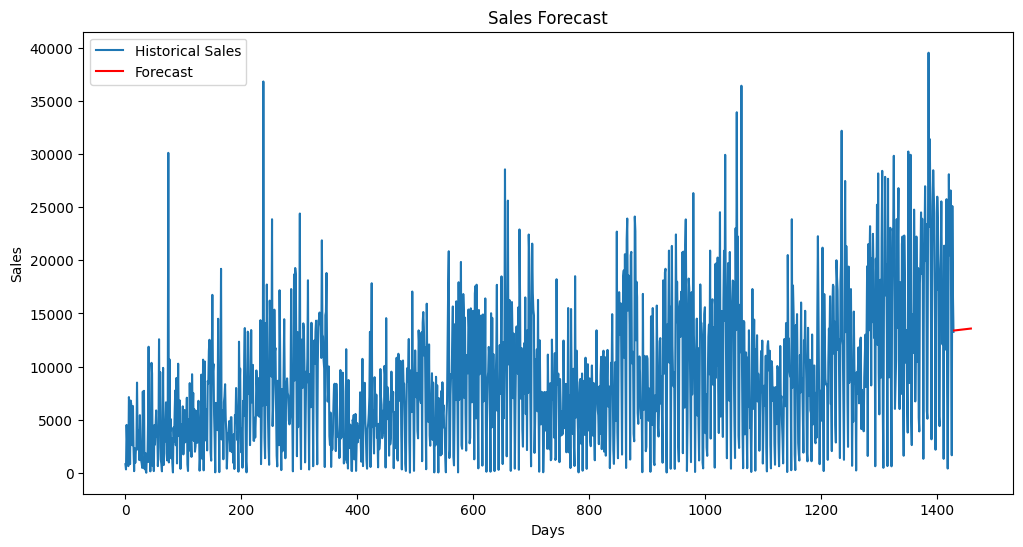

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(sales_data['Day_Number'],
         sales_data['sales'],
         label='Historical Sales')

plt.plot(future_days['Day_Number'],
         future_sales,
         color='red',
         label='Forecast')

plt.xlabel("Days")
plt.ylabel("Sales")
plt.title("Sales Forecast")

plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

pred = model.predict(X)

mae = mean_absolute_error(y, pred)
mse = mean_squared_error(y, pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 4710.260697165278
MSE: 36248189.626167655


In [ ]:
from prophet import Prophet

### Prophet Model for Time Series Forecasting

Prophet is a forecasting procedure developed by Facebook. It is particularly useful for time series data that exhibits strong seasonal effects and has several seasons of historical data.

To use Prophet, the DataFrame needs to have two columns: `ds` (datestamp) and `y` (metric to be forecasted).

In [ ]:
prophet_df = sales_data[['order_date', 'sales']].rename(columns={'order_date': 'ds', 'sales': 'y'})

print(prophet_df.head())

          ds     y
0 2011-01-01   808
1 2011-01-02   314
2 2011-01-03  4502
3 2011-01-04  2809
4 2011-01-05  3664


Now, let's instantiate and fit the Prophet model. We will then create a future DataFrame for predictions and plot the forecast.

In [ ]:
m = Prophet()
m.fit(prophet_df)

future = m.make_future_dataframe(periods=30)

forecast = m.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


          ds         yhat   yhat_lower    yhat_upper
0 2011-01-01  2984.141350 -2598.943452   8781.510750
1 2011-01-02 -2191.735997 -7445.286713   3207.934515
2 2011-01-03  7308.519186  2277.700275  12941.588406
3 2011-01-04  7098.686102  1698.164835  12523.065260
4 2011-01-05  6267.923947   885.316095  11783.817444


Finally, let's visualize the forecast. Prophet has a built-in plotting utility that can show the original data, the forecast, and the uncertainty intervals.

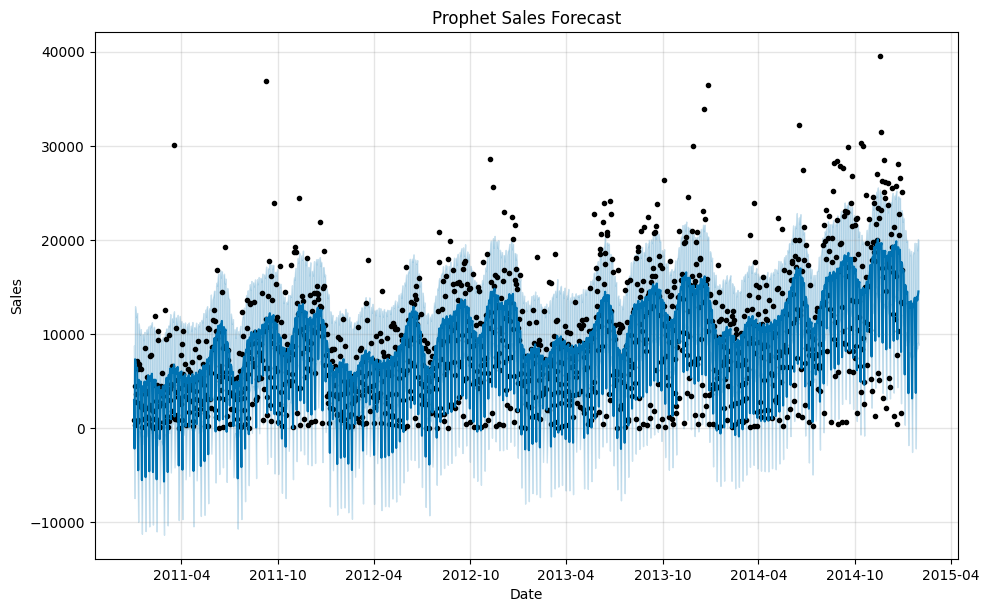

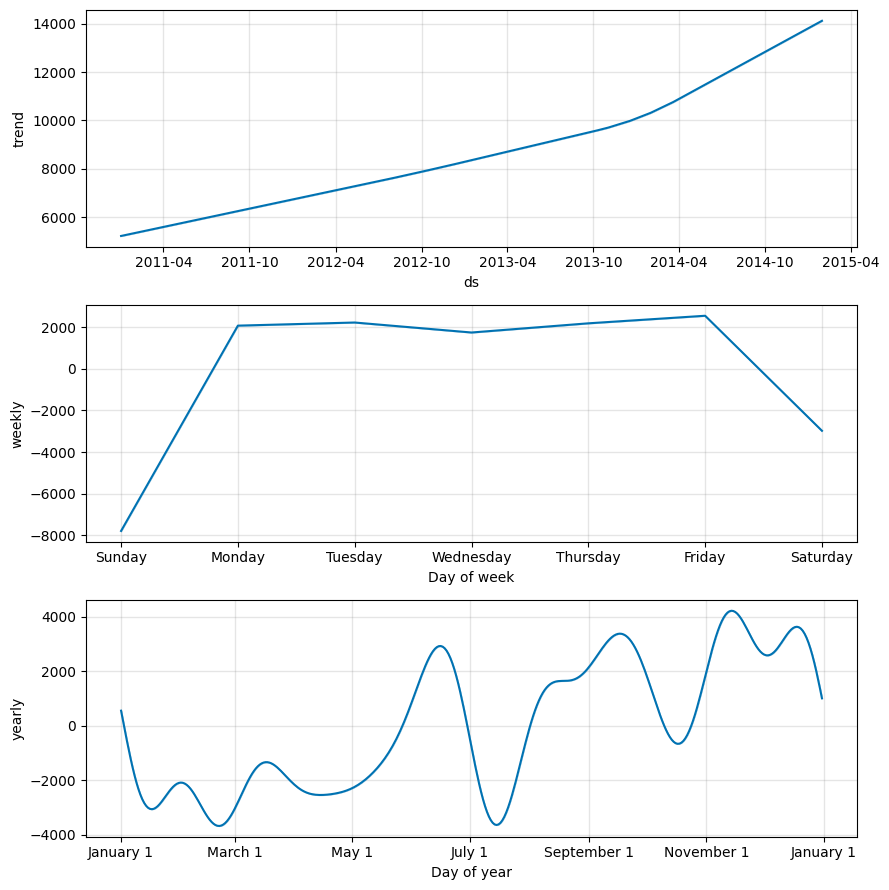

In [ ]:
fig = m.plot(forecast)
plt.title('Prophet Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

fig2 = m.plot_components(forecast)
plt.show()

### Weekly Seasonality Bar Graph

To get a clearer view of the weekly seasonality identified by Prophet, we can extract the weekly component from the `forecast` DataFrame and visualize it using a bar graph. This shows the average impact of each day of the week on sales.

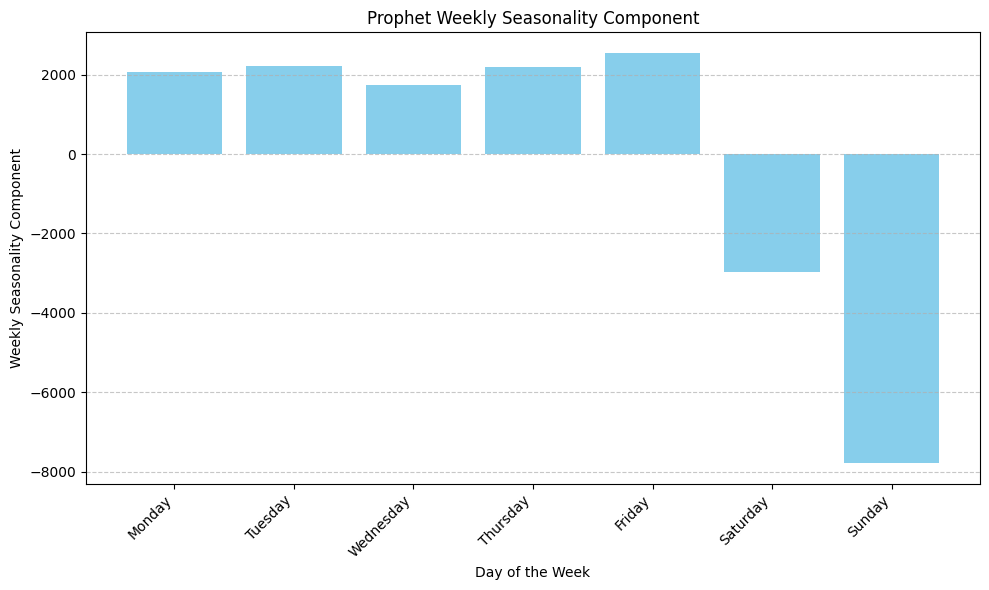

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


forecast['ds'] = pd.to_datetime(forecast['ds'])
forecast['day_of_week'] = forecast['ds'].dt.day_name()


weekly_seasonality = forecast.groupby('day_of_week')['weekly'].mean().reset_index()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_seasonality['day_of_week'] = pd.Categorical(weekly_seasonality['day_of_week'], categories=day_order, ordered=True)
weekly_seasonality = weekly_seasonality.sort_values('day_of_week')

plt.figure(figsize=(10, 6))
plt.bar(weekly_seasonality['day_of_week'], weekly_seasonality['weekly'], color='skyblue')
plt.xlabel('Day of the Week')
plt.ylabel('Weekly Seasonality Component')
plt.title('Prophet Weekly Seasonality Component')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()